# Customer Segmentation using Clustering

In this notebook, we perform customer segmentation using -

- K-Means Clustering
- Hierarchical Clustering
- DBSCAN

We analyze customer data based on income and spending behavior to identify meaningful groups.

This helps businesses - 
- Target customers effectively
- Improve marketing strategies
- Understand customer behavior

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [29]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Feature Selection

We select only the relevant features for clustering:

- **Annual Income**
- **Spending Score**

Clustering works better when we use meaningful and important features.
Here, we focus on customer purchasing behavior.

In [30]:
X = df[['Annual Income (k$)' , 'Spending Score (1-100)']]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

## Visualizing the Data

We create a scatter plot to visualize the relationship between:

- Annual Income
- Spending Score

This helps us:
- Understand the distribution of customers
- Identify possible clusters visually before applying algorithms

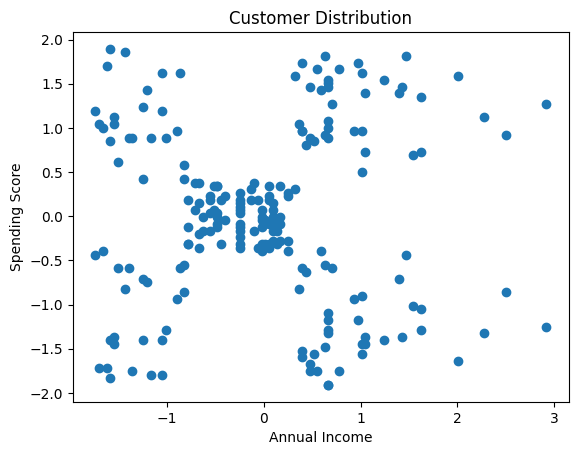

In [ ]:
plt.scatter(X[:,0],X[:,1]) #first(income) and second column(score)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

## Finding Optimal Clusters (Elbow Method)

We use the Elbow Method to determine the best number of clusters (K)
The "elbow point" (where the curve bends) indicates the optimal number of clusters.

- Lower WCSS = better clustering
- We choose K where improvement slows down

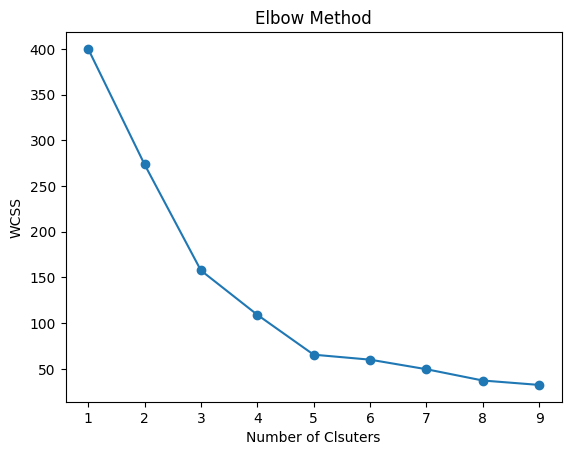

In [ ]:
from sklearn.cluster import KMeans

# WCSS = how compact your clusters are
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i,random_state=42) #here n_clusters= i means number of clusters
    kmeans.fit(X) # train model
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clsuters")
plt.ylabel("WCSS")
plt.show()

In [41]:
kmeans = KMeans(n_clusters=5,random_state=42)
y_kmeans = kmeans.fit_predict(X)

## Applying K-Means Clustering

We apply K-Means with the optimal number of clusters (K = 5).

`fit_predict()`:
  Fits the model to the data , 
  Assigns each data point to a cluster

The result is a cluster label for each customer.

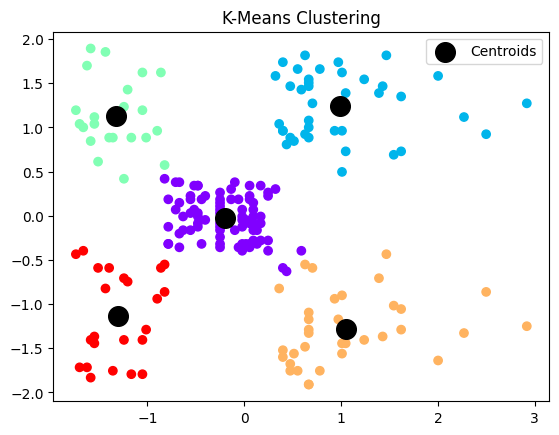

In [42]:
plt.scatter(X[:,0] , X[:,1],c=y_kmeans,cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],
            s=200,c='black',label='Centroids')
plt.legend()
plt.title("K-Means Clustering")
plt.show()

### Hierarchical clustering

A dendrogram is a tree-like diagram used to visualize clustering.

- It shows how clusters are merged step by step
- The height represents distance between clusters

We use the "ward" method to minimize variance within clusters.

This helps us decide the optimal number of clusters.

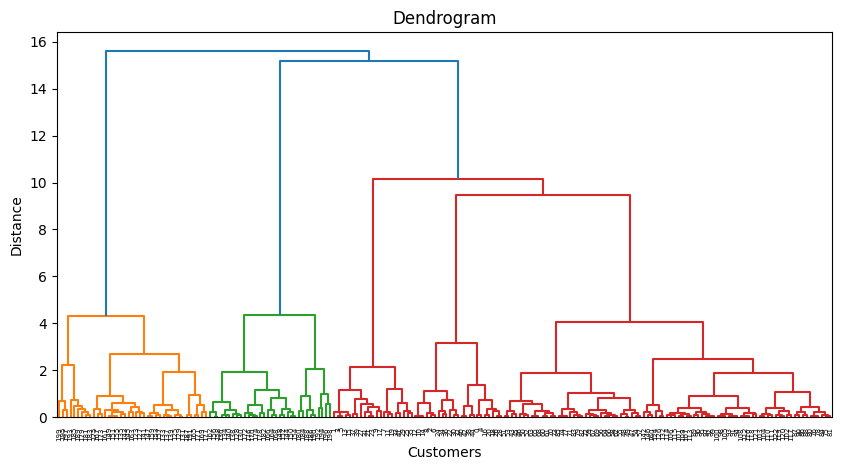

In [ ]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X,method="ward")) # here linkage - compute cluster distance and ward - minimizes variance
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [44]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)

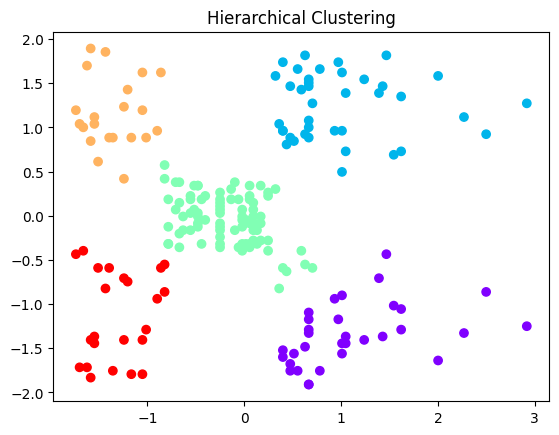

In [45]:
plt.scatter(X[:,0] , X[:,1],c=y_hc,cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.show()

### DBSCAN

DBSCAN is a density-based clustering algorithm.

Parameters:

eps: Radius for neighborhood 

min_samples: Minimum points required to form a cluster

It groups dense regions and identifies outliers (noise).

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=3,min_samples=5) # here eps = radius and min_samples- minimum points to form cluster
y_db = db.fit_predict(X)


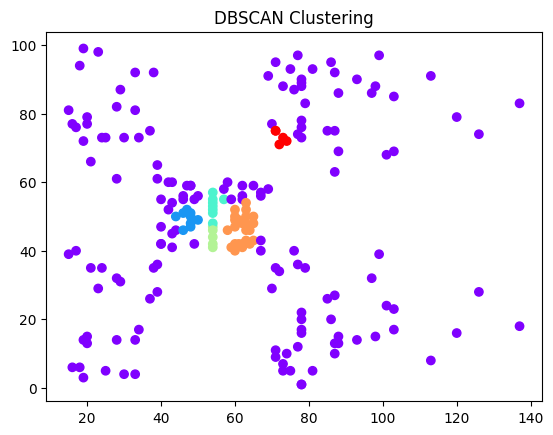

In [ ]:
plt.scatter(X[:,0] , X[:,1],c=y_db,cmap='rainbow') 
plt.title("DBSCAN Clustering")
plt.show()

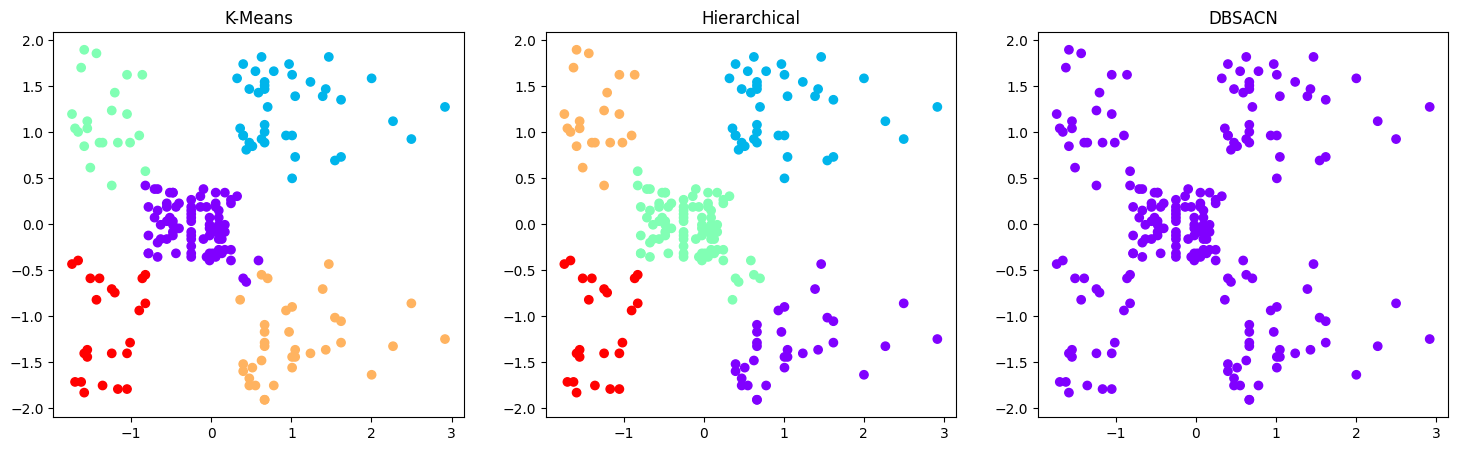

In [48]:
fig , axs = plt.subplots(1,3,figsize=(18,5))

axs[0].scatter(X[:,0] , X[:,1],c=y_kmeans,cmap='rainbow')
axs[0].set_title("K-Means")
axs[1].scatter(X[:,0] , X[:,1],c=y_hc,cmap='rainbow')
axs[1].set_title("Hierarchical")
axs[2].scatter(X[:,0] , X[:,1],c=y_db,cmap='rainbow')
axs[2].set_title("DBSACN")

plt.show()

In [50]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_kmeans)
print("Silhouette Score (K-Means):", score)

Silhouette Score (K-Means): 0.5546571631111091
